# 05 · Zarr space–time cubes and SQL views

**Decision question.** How can a bounded cube support maps, neighborhood summaries, and reproducible queries?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install('emfs:./wheels/asciitree-0.3.3-py3-none-any.whl')
    await micropip.install(['numpy', 'pandas', 'matplotlib', 'xarray==2025.9.0', 'zarr==2.18.7', 'plotly'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Three representations, one question

A cube preserves time and two spatial axes. A SQL table makes selection and grouping explicit. A map shows
where the result applies. Zarr stores arrays in chunks; SQL does not magically make every Zarr store a database.
Here we materialize a small selected subset into SQLite, which is available in Pyodide. The companion
project explores DuckDB-Wasm and larger browser workflows.

![Cube, rows, and views](assets/cube-to-table.svg)

The lesson pins Zarr 2.18.7 for its synchronous, browser-compatible in-memory store. It does not require a
threaded Zarr 3 runtime, distributed scheduler, cloud account, or remote object store.

In [2]:
import xarray as xr, zarr, sqlite3
lat=cells.lat.unique(); lon=cells.lon.unique()
ds=xr.Dataset({name:(('time','lat','lon'),values.astype('float32')) for name,values in cube.items()},
              coords={'time':pd.date_range('2025-01-01',periods=24,freq='MS'),'lat':lat,'lon':lon},
              attrs={'data_status':'synthetic','crs':'EPSG:4326','source':'rewiring.py, seed=2026'})
ds['heat_c'].attrs['units']='degree_Celsius'; ds['rain_mm'].attrs['units']='mm/month'
ds['cases'].attrs['units']='synthetic events/month'; ds['rate_per_1000'].attrs['units']='events/1000 people/month'
store=zarr.storage.MemoryStore()
encoding={name:{'chunks':(6,4,4)} for name in cube}
ds.to_zarr(store,mode='w',encoding=encoding,consolidated=True)
restored=xr.open_zarr(store,chunks=None,consolidated=True)
assert np.allclose(restored.heat_c,ds.heat_c)
print('Zarr',zarr.__version__,'| stored keys:',len(store),'| bytes:',sum(len(v) for v in store.values()))
display(restored)

Zarr 2.18.7 | stored keys: 84 | bytes: 28855


<xarray.Dataset> Size: 25kB
Dimensions:        (time: 24, lat: 8, lon: 8)
Coordinates:
  * lat            (lat) float64 64B -24.74 -24.71 -24.69 ... -24.59 -24.56
  * lon            (lon) float64 64B 25.86 25.89 25.91 ... 25.99 26.01 26.04
  * time           (time) datetime64[ns] 192B 2025-01-01 ... 2026-12-01
Data variables:
    cases          (time, lat, lon) float32 6kB ...
    heat_c         (time, lat, lon) float32 6kB 30.7 32.3 31.31 ... 34.83 35.53
    rain_mm        (time, lat, lon) float32 6kB ...
    rate_per_1000  (time, lat, lon) float32 6kB ...
Attributes:
    crs:          EPSG:4326
    data_status:  synthetic
    source:       rewiring.py, seed=2026

## Chunk layout is a query design choice

Our 24×8×8 cube uses chunks of 6×4×4. A single monthly map intersects four chunks; one cell's full
history intersects four chunks. Reading one value can therefore require decoding additional values.
Cloud queries also have per-request latency, compression, and caching costs that this byte count omits.

In [3]:
shape=np.array([24,8,8]); chunks=np.array([6,4,4])
display(pd.DataFrame({'layout':['time-major (6,4,4)','spatial-slice (1,8,8)','point-history (24,1,1)'],
 'chunks_for_one_map':[4,1,64], 'chunks_for_one_history':[4,24,1],
 'float32_values_per_chunk':[96,64,24]}))
print('Raw bytes in one heat variable:',ds.heat_c.nbytes)

,layout,chunks_for_one_map,chunks_for_one_history,float32_values_per_chunk
0,"time-major (6,4,4)",4,4,96
1,"spatial-slice (1,8,8)",1,24,64
2,"point-history (24,1,1)",64,1,24


Raw bytes in one heat variable: 6144


## A parameterized SQL view with a denominator

We materialize months 1–12 only. SQL parameters keep data values separate from query syntax.
The query reports population-weighted temperature and an event rate from totals. Duplicating rows in a
join would bias both, so check row uniqueness before aggregation.

In [4]:
subset=panel[panel.month<12].copy()
assert not subset.duplicated(['month','cell_id']).any()
con=sqlite3.connect(':memory:')
subset.to_sql('observations',con,index=False,if_exists='replace')
con.execute('CREATE VIEW eastern_cells AS SELECT * FROM observations WHERE col >= 4')
sql="""SELECT month, SUM(population) AS population,
 SUM(heat_c*population)/SUM(population) AS weighted_heat_c,
 1000.0*SUM(cases)/SUM(population) AS events_per_1000
 FROM eastern_cells WHERE heat_c >= ? GROUP BY month ORDER BY month"""
result=pd.read_sql_query(sql,con,params=(28.0,))
display(result)
assert (result.population>0).all()
con.close()

,month,population,weighted_heat_c,events_per_1000
0,0,44137,33.941523,27.709178
1,1,44137,33.241535,27.301357
2,2,44137,31.507658,24.854431
3,3,37819,29.075111,20.175044
4,4,3625,28.584761,17.655172
5,9,39340,29.312694,22.928317
6,10,44137,31.839090,25.488819
7,11,44137,33.391019,28.071686


## Orbit a space–time cube

The third axis below is **month**, not height. Markers are cell centers, colored by temperature.
The filter selects hot values, so empty space means “excluded by the filter”, not missing data or zero.
Use the slider in the [linked demo](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) for a 2D alternative.

In [5]:
import plotly.graph_objects as go
selected=panel[panel.heat_c>=30]
fig=go.Figure(go.Scatter3d(x=selected.lon,y=selected.lat,z=selected.month+1,mode='markers',
 marker=dict(size=3,color=selected.heat_c,colorscale='Magma',colorbar=dict(title='°C')),
 text=selected.cell_id,hovertemplate='Cell %{text}<br>lon %{x}<br>lat %{y}<br>month %{z}<extra></extra>'))
fig.update_layout(title='Synthetic space–time cube: heat ≥ 30°C',height=520,
 scene=dict(xaxis_title='Longitude',yaxis_title='Latitude',zaxis_title='Month'))
display(HTML(fig.to_html(full_html=False,include_plotlyjs='cdn')))

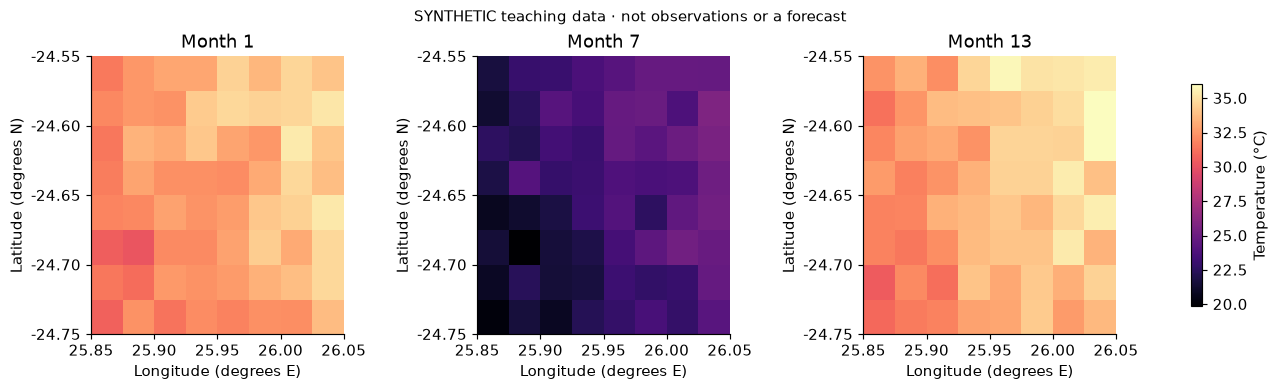

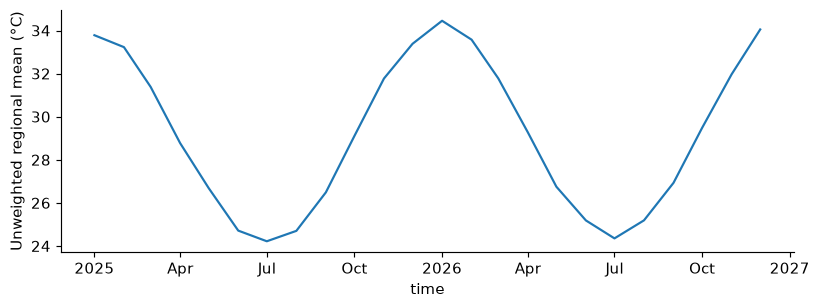

In [6]:
map_matrix(restored.heat_c.isel(time=[0,6,12]).values,['Month 1','Month 7','Month 13'],'Temperature (°C)',cmap='magma')
plt.show()
region=restored.heat_c.sel(lon=slice(25.95,26.05)).mean(['lat','lon'])
region.plot(figsize=(9,3)); plt.ylabel('Unweighted regional mean (°C)'); plt.show()

## Investigate, interpret, and discuss

1. Change chunk shapes and calculate read amplification for one monthly map.
2. Replace the eastern-cell view with the western half. Keep units, filter, and denominators visible.
3. Explain why filtering on heat changes the population included in each monthly rate.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- [Zarr 2 documentation](https://zarr.readthedocs.io/en/v2.18.7/) and [xarray Zarr I/O](https://docs.xarray.dev/en/stable/user-guide/io.html#zarr).
- [SQLite](https://sqlite.org/) and [DuckDB-Wasm](https://duckdb.org/docs/stable/clients/wasm/overview).
- [jltobias/Zarr SQL teaching atlas](https://github.com/jltobias/JupyterLite-zarr-sql-views), itself inspired by [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views). No upstream implementation code is copied in this lesson.

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).